# TS7 - Filtrado digital lineal de ECG

## Objetivos

En esta tarea se diseñan filtros digitales para eliminar distintas fuentes de contaminación presentes en una señal electrocardiográfica (ECG) registrada durante una prueba de esfuerzo.

Las principales interferencias presentes en la señal son:

- Movimiento de línea de base asociado a la respiración.
- Ruido muscular.
- Ruido producido por movimiento de electrodos.

Se diseñan y comparan filtros FIR e IIR utilizando distintas metodologías de diseño disponibles en SciPy, verificando posteriormente su desempeño sobre el registro real de ECG.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal as sig

from pytc2.sistemas_lineales import plot_plantilla

# Lectura del ECG

Se carga el registro ECG suministrado por la cátedra junto con los patrones promedio de latidos normales y ventriculares que serán utilizados como referencia cualitativa para evaluar el resultado del filtrado.

In [2]:
fs = 1000

mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()
qrs_pattern1 = mat_struct['qrs_pattern1'].flatten()
heartbeat_pattern1 = mat_struct['heartbeat_pattern1'].flatten()
heartbeat_pattern2 = mat_struct['heartbeat_pattern2'].flatten()
qrs_detections = mat_struct['qrs_detections'].flatten()

cant_muestras = len(ecg_one_lead)

# Plantilla de diseño

La plantilla se obtuvo a partir de la estimación de ancho de banda realizada en la TS5.

Se observó que la mayor parte de la energía útil del ECG se encuentra por debajo de los 35 Hz.

Por otra parte:

- Las componentes por debajo de 1 Hz están asociadas al movimiento de línea de base.
- Las componentes por encima de 35 Hz contienen principalmente ruido muscular y ruido generado por movimiento de electrodos.

Por este motivo se definió una plantilla pasabanda con:

- Banda de paso: 1 Hz a 35 Hz.
- Banda de rechazo inferior: por debajo de 0.1 Hz.
- Banda de rechazo superior: por encima de 45 Hz.
- Ripple máximo: 1 dB.
- Atenuación mínima: 40 dB.

In [6]:
wp1 = 1
wp2 = 35

ws1 = 0.1
ws2 = 45

gpass = 1
gstop = 40

wp = (wp1, wp2)
ws = (ws1, ws2)

# Frecuencias para evaluar las respuestas
ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500),
    np.linspace(start=1.26, stop=35, num=300),
    np.linspace(start=35.1, stop=60, num=300),
    np.linspace(start=61, stop=fs//2, num=200)
])

ww = np.sort(ww)

# Diseño de filtros FIR

Se diseñaron dos filtros FIR:

1. Método de ventanas (`firwin2`).
2. Método de cuadrados mínimos (`firls`).

Para el diseño mediante ventanas se utilizó una ligera modificación de las frecuencias de transición con el objetivo de cumplir adecuadamente la plantilla especificada.

## FIR por ventanas

La respuesta obtenida verifica la plantilla propuesta, permitiendo conservar la banda útil del ECG y atenuar las componentes asociadas al ruido de baja y alta frecuencia.

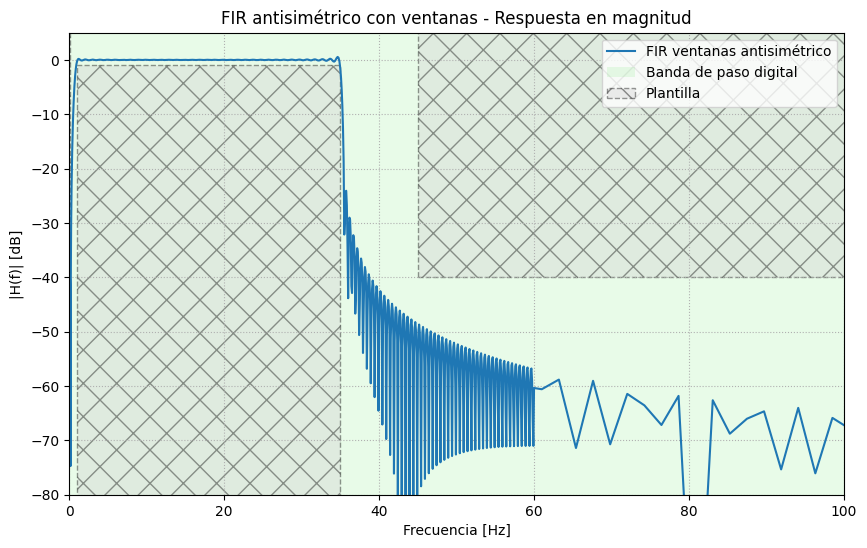

In [7]:
#%% HACK usado sólo para el diseño FIR

# La plantilla oficial se mantiene para verificar.
# Estos valores se usan internamente para lograr que los FIR cumplan mejor.
wp1_hack = 1
wp2_hack = 35
ws1_hack = 0.3
ws2_hack = 35.4

freq_fir = np.array([0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs/2])
gain_fir = np.array([0, 0, 1, 1, 0, 0])

#%% FIR 1 - Ventanas antisimétrico

numtaps = 2000

fir_win_ant = sig.firwin2(numtaps,
                          freq_fir,
                          gain_fir,
                          nfreqs=2**14,
                          window='boxcar',
                          fs=fs,
                          antisymmetric=True)

w_fir_ant, h_fir_ant = sig.freqz(fir_win_ant,
                                 worN=ww,
                                 fs=fs)

plt.figure(figsize=(10,6))

plt.plot(w_fir_ant,
         20*np.log10(np.abs(h_fir_ant) + 1e-12),
         label='FIR ventanas antisimétrico')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('FIR antisimétrico con ventanas - Respuesta en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

## FIR por cuadrados mínimos

El filtro diseñado mediante cuadrados mínimos presenta una transición más abrupta y una mejor aproximación a la respuesta deseada en comparación con el método de ventanas.

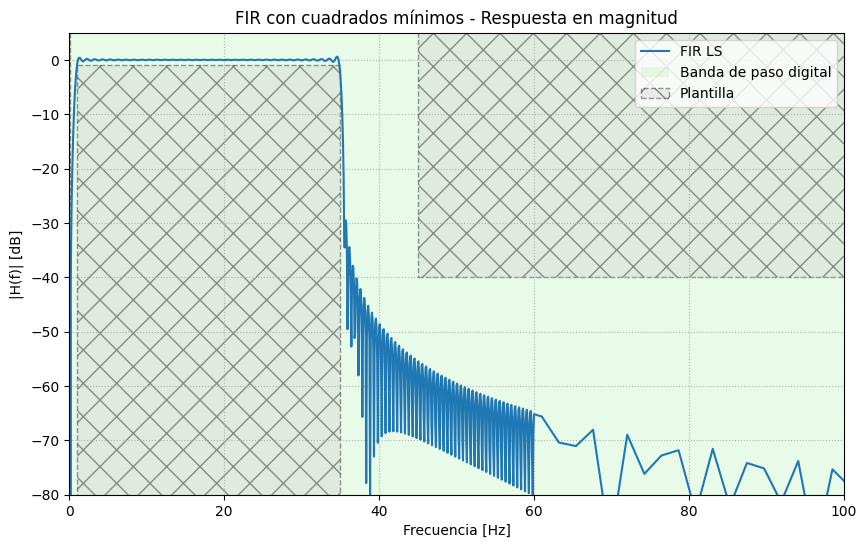

In [8]:
#%% FIR 2 - Cuadrados mínimos

numtaps_ls = 2001

band = [0, ws1_hack, wp1_hack, wp2_hack, ws2_hack, fs/2]
gain = [0, 0, 1, 1, 0, 0]
weight = [10, 1, 5]

fir_ls = sig.firls(numtaps_ls,
                   band,
                   gain,
                   weight=weight,
                   fs=fs)

ls_fir, h_fir_ls = sig.freqz(fir_ls,
                             worN=ww,
                             fs=fs)

plt.figure(figsize=(10,6))

plt.plot(ls_fir,
         20*np.log10(np.abs(h_fir_ls) + 1e-12),
         label='FIR LS')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('FIR con cuadrados mínimos - Respuesta en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

# Diseño de filtros IIR

Se diseñaron tres filtros IIR para comparar su desempeño:

- Butterworth.
- Chebyshev tipo II.
- Cauer (Elíptico).

Para compensar la distorsión de fase característica de los filtros IIR, todos fueron aplicados utilizando filtrado bidireccional (`filtfilt`).

## IIR Butterworth

El filtro Butterworth presenta máxima planicidad en la banda de paso y una transición relativamente suave.

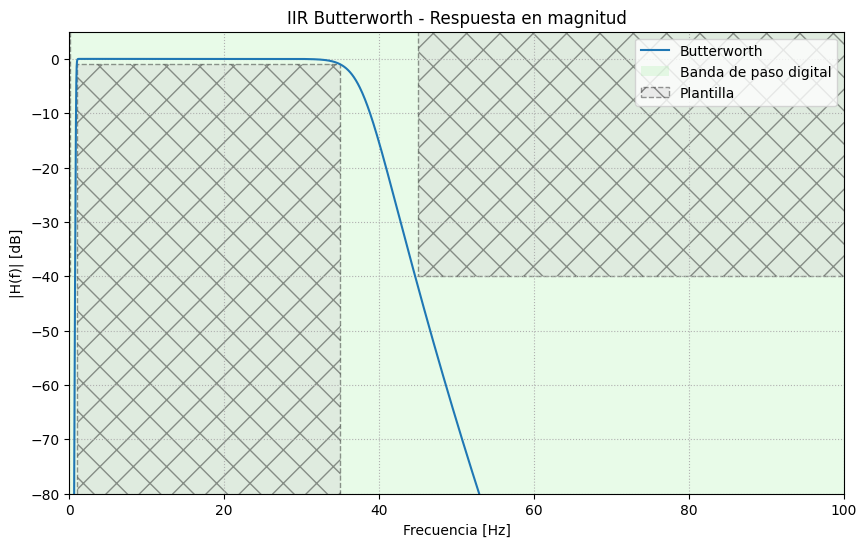

In [9]:
#%% IIR 1 - Butterworth

sos_butter = sig.iirdesign(wp,
                           ws,
                           gpass/2,
                           gstop/2,
                           analog=False,
                           ftype='butter',
                           output='sos',
                           fs=fs)

w_butter, h_butter = sig.sosfreqz(sos_butter,
                                  worN=ww,
                                  fs=fs)

h_butter_eff = h_butter**2

plt.figure(figsize=(10,6))

plt.plot(w_butter,
         20*np.log10(np.abs(h_butter_eff) + 1e-12),
         label='Butterworth')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('IIR Butterworth - Respuesta en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

## IIR Chebyshev II

El filtro Chebyshev tipo II permite obtener una transición más abrupta manteniendo una banda de paso libre de ripple.

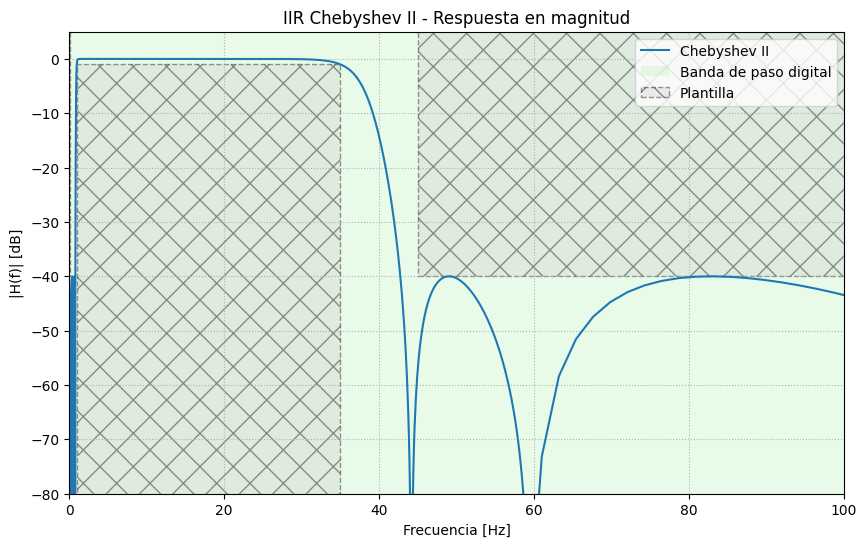

In [10]:
#%% IIR 2 - Chebyshev II

sos_cheby2 = sig.iirdesign(wp,
                           ws,
                           gpass/2,
                           gstop/2,
                           analog=False,
                           ftype='cheby2',
                           output='sos',
                           fs=fs)

w_cheby2, h_cheby2 = sig.sosfreqz(sos_cheby2,
                                  worN=ww,
                                  fs=fs)

h_cheby2_eff = h_cheby2**2

plt.figure(figsize=(10,6))

plt.plot(w_cheby2,
         20*np.log10(np.abs(h_cheby2_eff) + 1e-12),
         label='Chebyshev II')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('IIR Chebyshev II - Respuesta en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

## IIR Cauer

El filtro Cauer presenta la transición más abrupta entre las alternativas analizadas, a costa de introducir ripple tanto en banda de paso como en banda de rechazo.

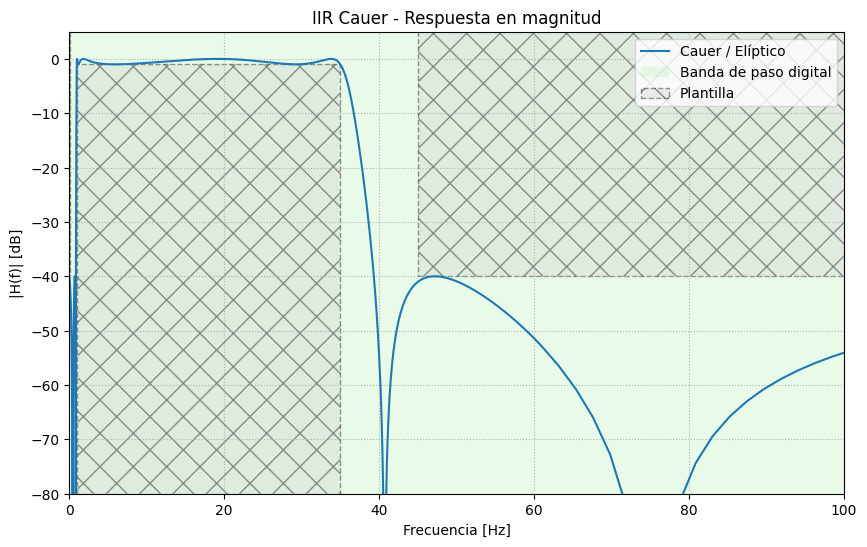

In [11]:
#%% IIR 3 - Cauer / Elíptico

sos_cauer = sig.iirdesign(wp,
                          ws,
                          gpass/2,
                          gstop/2,
                          analog=False,
                          ftype='ellip',
                          output='sos',
                          fs=fs)

w_cauer, h_cauer = sig.sosfreqz(sos_cauer,
                                worN=ww,
                                fs=fs)

h_cauer_eff = h_cauer**2

plt.figure(figsize=(10,6))

plt.plot(w_cauer,
         20*np.log10(np.abs(h_cauer_eff) + 1e-12),
         label='Cauer / Elíptico')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('IIR Cauer - Respuesta en magnitud')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

# Comparación de respuestas en frecuencia

Se comparan las respuestas en frecuencia de los cinco filtros diseñados junto con la plantilla de diseño establecida previamente.

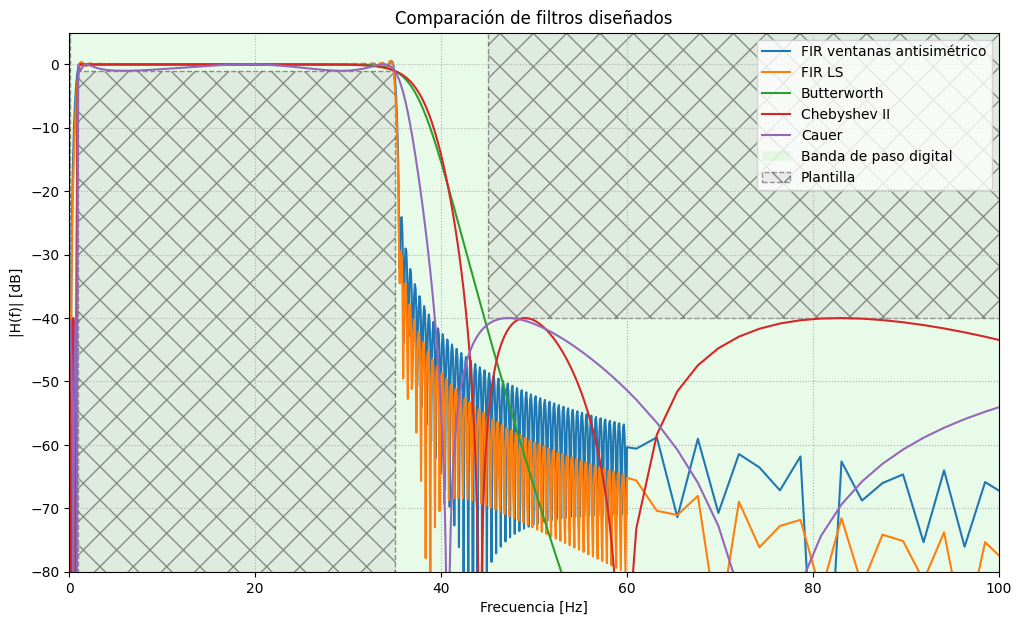

In [13]:
#%% Comparación de todas las respuestas

plt.figure(figsize=(12,7))

plt.plot(w_fir_ant,
         20*np.log10(np.abs(h_fir_ant) + 1e-12),
         label='FIR ventanas antisimétrico')

plt.plot(ls_fir,
         20*np.log10(np.abs(h_fir_ls) + 1e-12),
         label='FIR LS')

plt.plot(w_butter,
         20*np.log10(np.abs(h_butter_eff) + 1e-12),
         label='Butterworth')

plt.plot(w_cheby2,
         20*np.log10(np.abs(h_cheby2_eff) + 1e-12),
         label='Chebyshev II')

plt.plot(w_cauer,
         20*np.log10(np.abs(h_cauer_eff) + 1e-12),
         label='Cauer')

plot_plantilla(
    filter_type='bandpass',
    fpass=wp,
    ripple=gpass,
    fstop=ws,
    attenuation=gstop,
    fs=fs
)

plt.title('Comparación de filtros diseñados')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('|H(f)| [dB]')
plt.xlim([0, 100])
plt.ylim([-80, 5])
plt.grid(True, which='both', ls=':')
plt.legend()
plt.show()

# Comparación de fase

Además de la respuesta en magnitud, resulta importante analizar la respuesta en fase de cada filtro.

En aplicaciones biomédicas la preservación de la forma temporal de los complejos QRS puede ser tan importante como la atenuación del ruido.

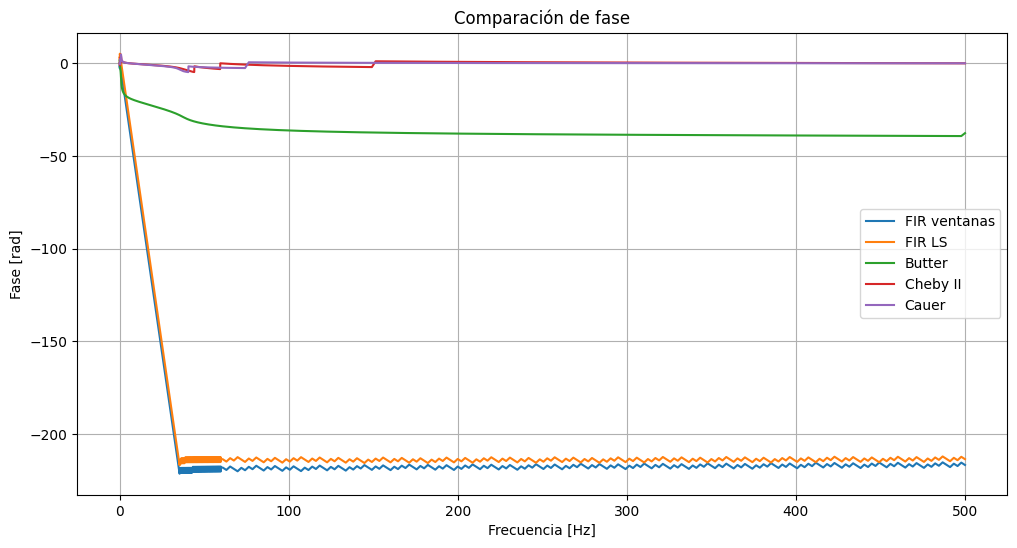

In [14]:
#%% Comparación de fase

plt.figure(figsize=(12,6))

plt.plot(w_fir_ant,
         np.unwrap(np.angle(h_fir_ant)),
         label='FIR ventanas')

plt.plot(ls_fir,
         np.unwrap(np.angle(h_fir_ls)),
         label='FIR LS')

plt.plot(w_butter,
         np.unwrap(np.angle(h_butter)),
         label='Butter')

plt.plot(w_cheby2,
         np.unwrap(np.angle(h_cheby2)),
         label='Cheby II')

plt.plot(w_cauer,
         np.unwrap(np.angle(h_cauer)),
         label='Cauer')

plt.title('Comparación de fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.grid()
plt.legend()

plt.show()


# Retardo de grupo

El retardo de grupo permite evaluar cuánto se desplazan temporalmente las distintas componentes espectrales.

Los filtros FIR suelen presentar retardo aproximadamente constante mientras que los filtros IIR presentan retardo dependiente de la frecuencia.

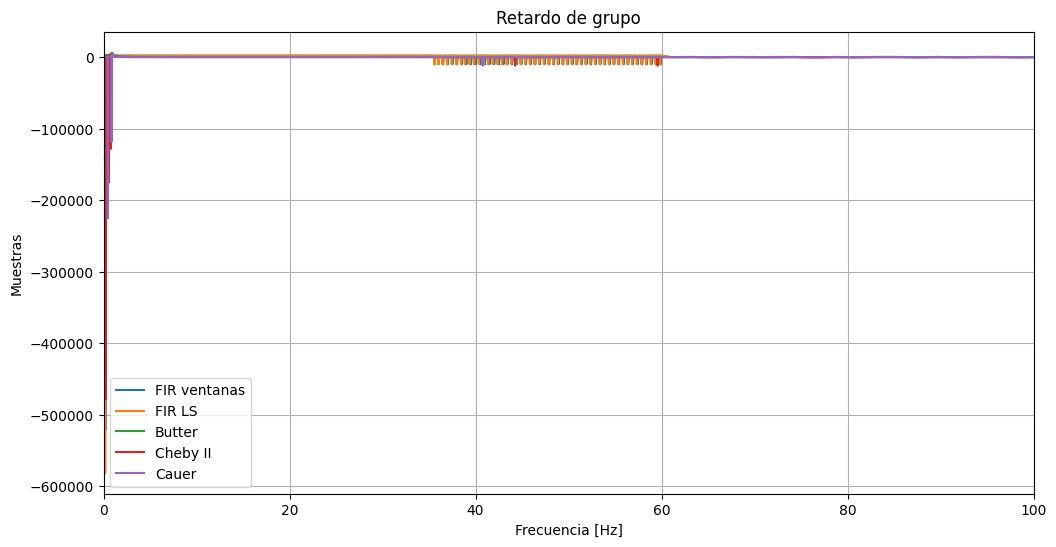

In [15]:
#%% Retardo de grupo
# FIR

fase_fir_ant = np.unwrap(np.angle(h_fir_ant))
gd_fir_ant = -np.diff(fase_fir_ant) / np.diff(w_fir_ant/fs*np.pi)

fase_fir_ls = np.unwrap(np.angle(h_fir_ls))
gd_fir_ls = -np.diff(fase_fir_ls) / np.diff(ls_fir/fs*np.pi)

#IIR

fase_butter = np.unwrap(np.angle(h_butter))
gd_butter = -np.diff(fase_butter) / np.diff(w_butter/fs*np.pi)

fase_cheby = np.unwrap(np.angle(h_cheby2))
gd_cheby = -np.diff(fase_cheby) / np.diff(w_cheby2/fs*np.pi)

fase_cauer = np.unwrap(np.angle(h_cauer))
gd_cauer = -np.diff(fase_cauer) / np.diff(w_cauer/fs*np.pi)

plt.figure(figsize=(12,6))

plt.plot(w_fir_ant[1:], gd_fir_ant,
         label='FIR ventanas')

plt.plot(ls_fir[1:], gd_fir_ls,
         label='FIR LS')

plt.plot(w_butter[1:], gd_butter,
         label='Butter')

plt.plot(w_cheby2[1:], gd_cheby,
         label='Cheby II')

plt.plot(w_cauer[1:], gd_cauer,
         label='Cauer')

plt.xlim([0,100])

plt.title('Retardo de grupo')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Muestras')
plt.grid()
plt.legend()

plt.show()

# Aplicación de los filtros al ECG

Los filtros diseñados se aplican sobre el registro ECG para evaluar su capacidad de eliminación de ruido y preservación de la morfología de los latidos.

In [16]:
#%% Filtrado del ECG

ecg_firwin = sig.filtfilt(fir_win_ant, 1., ecg_one_lead)
ecg_firls = sig.filtfilt(fir_ls, 1., ecg_one_lead)

ecg_butter = sig.sosfiltfilt(sos_butter, ecg_one_lead)
ecg_cheby2 = sig.sosfiltfilt(sos_cheby2, ecg_one_lead)
ecg_cauer = sig.sosfiltfilt(sos_cauer, ecg_one_lead)


## Comparación global

Visualmente se observa una reducción importante de las componentes de baja y alta frecuencia manteniendo la estructura general de los complejos QRS.

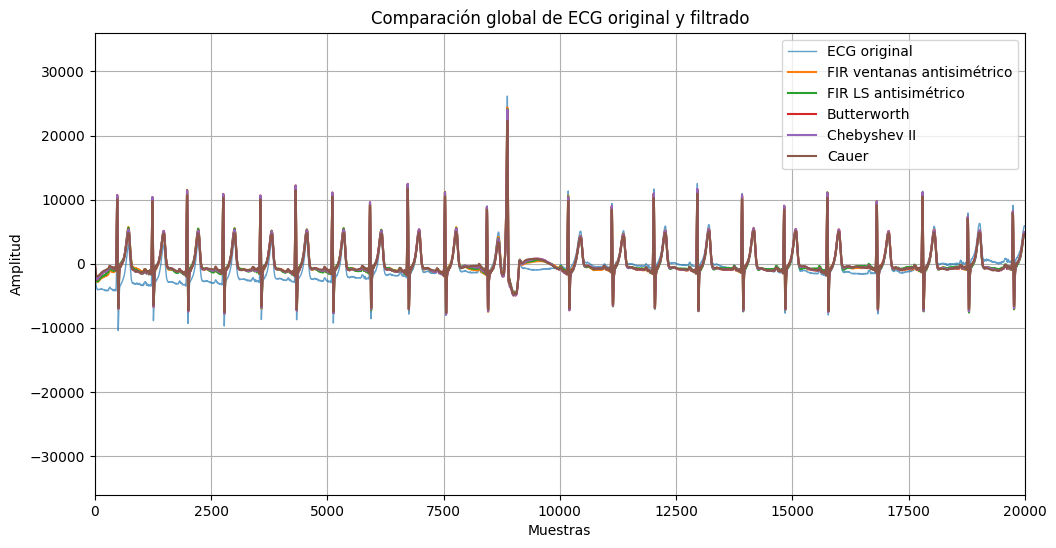

In [17]:
#%% Comparación global

plt.figure(figsize=(12,6))

plt.plot(ecg_one_lead,
         label='ECG original',
         linewidth=1,
         alpha=0.7)

plt.plot(ecg_firwin,
         label='FIR ventanas antisimétrico')

plt.plot(ecg_firls,
         label='FIR LS antisimétrico')

plt.plot(ecg_butter,
         label='Butterworth')

plt.plot(ecg_cheby2,
         label='Chebyshev II')

plt.plot(ecg_cauer,
         label='Cauer')

plt.title('Comparación global de ECG original y filtrado')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.xlim([0, 20000])
plt.grid()
plt.legend()
plt.show()

## Regiones sin ruido

En estas regiones se verifica que los filtros no introduzcan distorsiones apreciables sobre la morfología original del ECG.

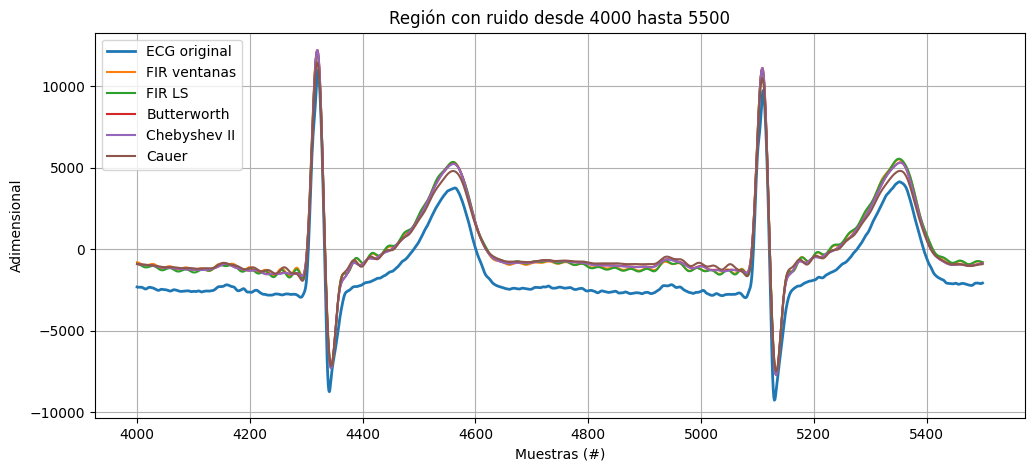

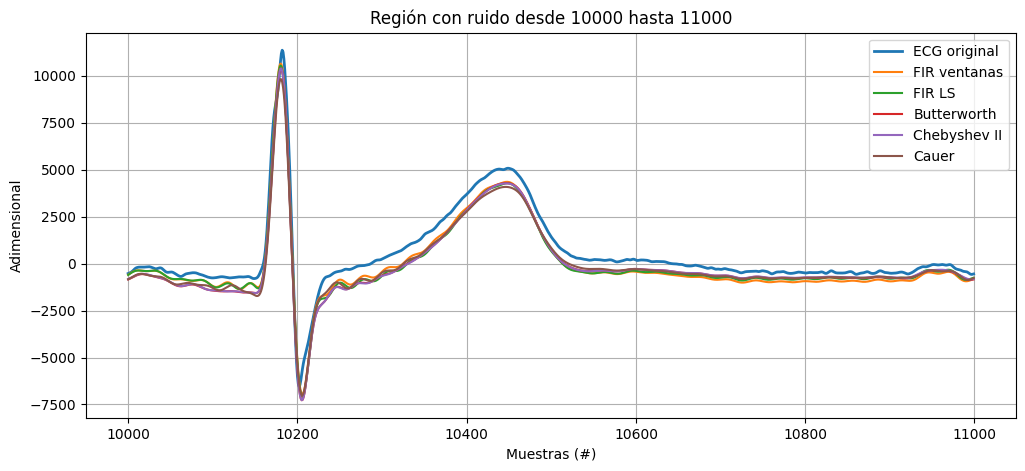

In [18]:
#%% Regiones de interés con ruido

regs_interes = (
    [4000, 5500],
    [10000, 11000],
)

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras, ii[1]]),
        dtype='uint'
    )

    plt.figure(figsize=(12,5))

    plt.plot(zoom_region,
             ecg_one_lead[zoom_region],
             label='ECG original',
             linewidth=2)

    plt.plot(zoom_region,
             ecg_firwin[zoom_region],
             label='FIR ventanas')

    plt.plot(zoom_region,
             ecg_firls[zoom_region],
             label='FIR LS')

    plt.plot(zoom_region,
             ecg_butter[zoom_region],
             label='Butterworth')

    plt.plot(zoom_region,
             ecg_cheby2[zoom_region],
             label='Chebyshev II')

    plt.plot(zoom_region,
             ecg_cauer[zoom_region],
             label='Cauer')

    plt.title('Región con ruido desde ' + str(ii[0]) + ' hasta ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.grid()
    plt.legend()
    plt.show()

## Regiones con ruido

En estas regiones puede observarse la capacidad de cada filtro para reducir las perturbaciones presentes en la señal original.

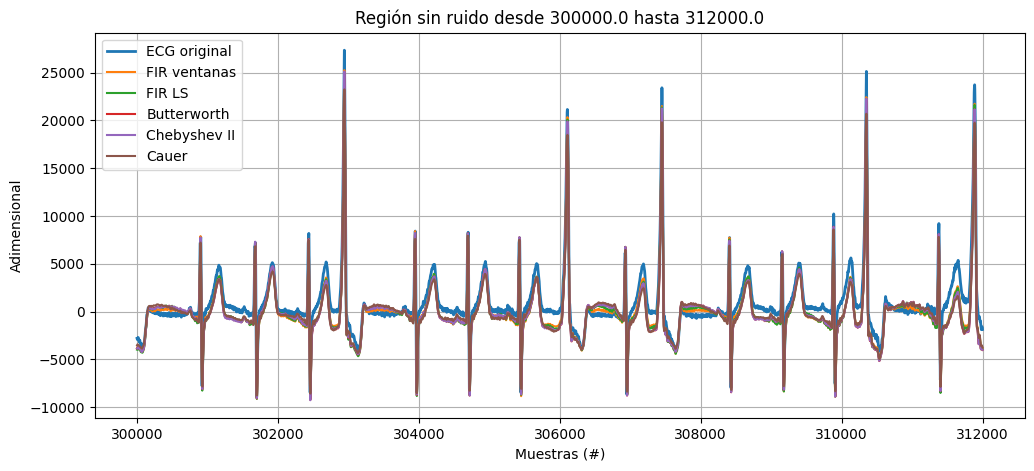

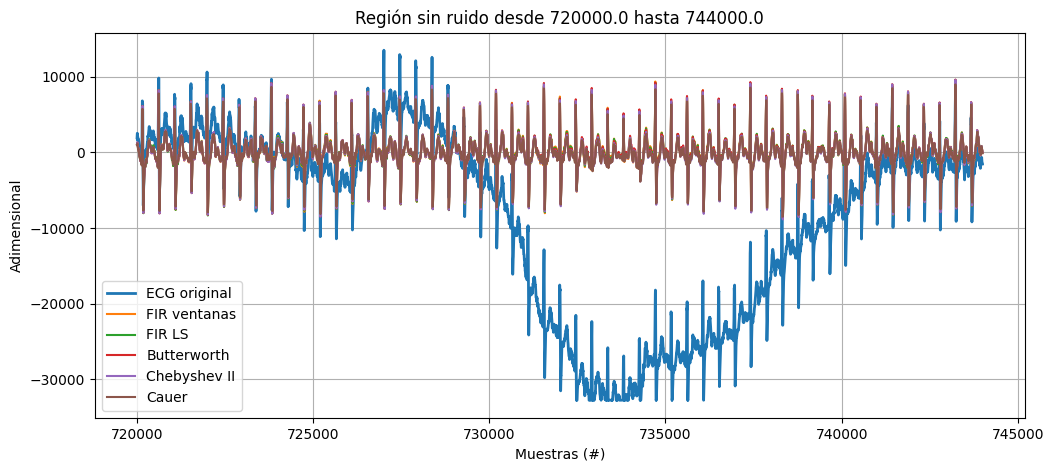

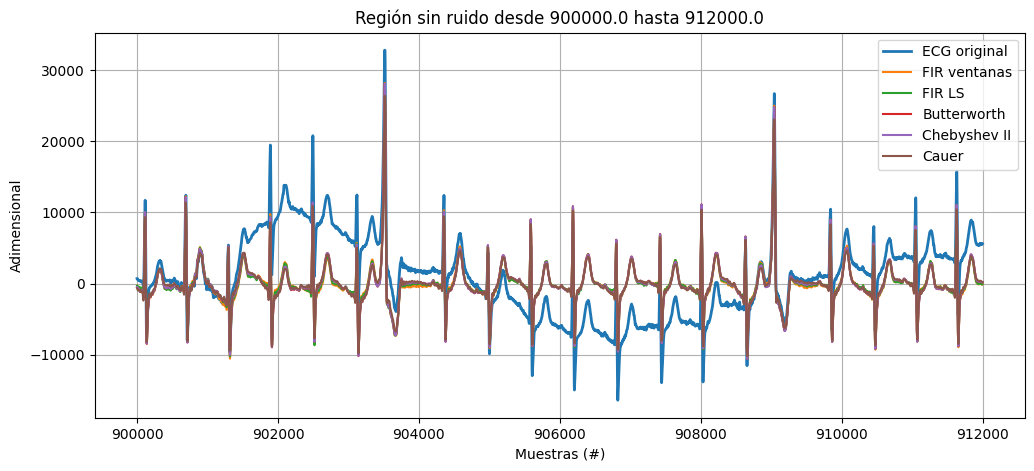

In [19]:
#%% Regiones de interés sin ruido

regs_interes = (
    np.array([5, 5.2]) * 60 * fs,
    np.array([12, 12.4]) * 60 * fs,
    np.array([15, 15.2]) * 60 * fs,
)

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras, ii[1]]),
        dtype='uint'
    )

    plt.figure(figsize=(12,5))

    plt.plot(zoom_region,
             ecg_one_lead[zoom_region],
             label='ECG original',
             linewidth=2)

    plt.plot(zoom_region,
             ecg_firwin[zoom_region],
             label='FIR ventanas')

    plt.plot(zoom_region,
             ecg_firls[zoom_region],
             label='FIR LS')

    plt.plot(zoom_region,
             ecg_butter[zoom_region],
             label='Butterworth')

    plt.plot(zoom_region,
             ecg_cheby2[zoom_region],
             label='Chebyshev II')

    plt.plot(zoom_region,
             ecg_cauer[zoom_region],
             label='Cauer')

    plt.title('Región sin ruido desde ' + str(ii[0]) + ' hasta ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
    plt.grid()
    plt.legend()
    plt.show()

# Conclusiones

Todos los filtros diseñados verificaron satisfactoriamente la plantilla de diseño establecida para el ECG.

Los filtros FIR presentaron una fase aproximadamente lineal y un retardo de grupo prácticamente constante, preservando la forma temporal de la señal. Como desventaja, requirieron órdenes considerablemente mayores y por lo tanto un mayor costo computacional.

Los filtros IIR lograron una selectividad similar utilizando órdenes mucho menores. Esto reduce la cantidad de operaciones necesarias y resulta ventajoso para implementaciones en tiempo real o sistemas embebidos. Sin embargo, presentan fase no lineal y retardo de grupo variable.

Entre los filtros IIR analizados, el filtro Cauer presentó la transición más abrupta, mientras que Butterworth mostró la respuesta más suave y libre de ripple.

Para procesamiento fuera de línea, donde puede utilizarse filtrado bidireccional (`filtfilt`), los filtros IIR resultan particularmente atractivos debido a su bajo costo computacional y excelente desempeño.

En aplicaciones donde la preservación de la fase es crítica, los filtros FIR constituyen una alternativa más adecuada a costa de una mayor complejidad de implementación.